# Question 1: Illegal Desposed Waste and Littering in the neighbourhoods of Zürich

Author: Tim Berger 
Date: 20.5.2026

#### Introduction
The Zürich wie neu website allows the residents of Zürich to report damage and defects of the infrastructure of the city. 
Reports are sorted in different categories, such as waste or graphity. 
Illegal disposed waste and littering in the "Abfall/ Sammelstelle" category is reported the most (see category frequency analysis).
As seen in the heatmap, the number of reports is, generally speaking, higher in the centre of Zürich, compared to the outer regions. But at the same time, also more people live in the city center compared to the outer regions. Therefore this analysis aims to compare the number of reports per resident for the neighbourhoods of Zurich.

#### Research Question: 
Do the waste report hotspots on the heatmap correlate with the reports per resident for the neighbourhoods of zurich?

#### Requirements
To be able to run this code, use the environment sds210 located in the github repository of this project.

import packages


In [25]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
from scipy import stats
import contextily as ctx

import notebook_utils

### Access and load data via Website of Zürich (züri wie neu, neighbourhoods, population)

In [26]:
# the notebook_utils file contains all the functions to load the required data from the website of the canton of zurich
# if a dataset failed to load, the corresponding url in the notebook utils file should be checked

zwn_gdf_raw = notebook_utils.import_zwn_data()
neighbourhoods_gdf_raw = notebook_utils.import_neighbourhood_data()
population_df_raw = notebook_utils.import_population_data()
income_df_raw = notebook_utils.import_income_data()
neighbourhood_labels_gdf_raw = notebook_utils.import_neighbourhood_label_data()


Data züri wie neu loaded sugessfull
neighbourhood data loaded sugessfull
Data Population loaded sugessfull
Data Income loaded sugessfull
neighbourhood label data loaded sugessfull


In [27]:
neighbourhood_labels_gdf_raw.head(5)

,id,geometrie_gdo,hali,kuerzel,name,objectid,objid,ori,vali,geometry
0,adm_statistische_quartiere_b_p.1,None,1.0,111,Affoltern,1,1,0.0,2.0,POINT (2680575.734 1253034.928)
1,adm_statistische_quartiere_b_p.2,None,1.0,119,Seebach,2,2,0.0,2.0,POINT (2683071.925 1253148.374)
2,adm_statistische_quartiere_b_p.3,None,1.0,121,Saatlen,3,3,0.0,2.0,POINT (2684968.443 1251835.388)
3,adm_statistische_quartiere_b_p.4,None,1.0,101,Höngg,4,4,0.0,2.0,POINT (2679781.476 1251349.152)
4,adm_statistische_quartiere_b_p.5,None,1.0,102,Wipkingen,5,5,0.0,2.0,POINT (2681888.621 1250165.901)


## Clean and Filter the Data

- clean population data

In [28]:
## filter population for the newest year

# display the current year
current_year = int(dt.date.today().year)

#filter dataframe for the newest year
population_df = population_df_raw[population_df_raw["StichtagDatJahr"] == str(current_year-1)].copy()

#clean the population data
#drop the columns not needed
population_df= population_df.drop(columns=["StichtagDatJahr", "QuarSort", "_id"])

#convert numbers to integer
population_df["AnzBestWir"] = population_df["AnzBestWir"].astype(int)

#rename the columns
population_df = population_df.rename(columns={"AnzBestWir": "population", "QuarLang": "qname"})



- clean züri wie neu data

In [29]:
# filter the züri wie neu data for waste
zwn_waste_gdf = zwn_gdf_raw[zwn_gdf_raw["service_name"]=="Abfall/Sammelstelle"].copy()

# filter for the required columns
zwn_waste_gdf = zwn_waste_gdf[["service_request_id", "title", "geometry"]]


- clean neighbourhood data

In [30]:
#filter neighbourhoods data for required columns 
neighbourhoods_gdf = neighbourhoods_gdf_raw[["qname", "qnr", "geometry"]]

# filter the neighbourhood label data for required columns
neighbourhood_labels_gdf = neighbourhood_labels_gdf_raw[["name", "geometry"]].copy()

neighbourhood_labels_gdf.head(5)


,name,geometry
0,Affoltern,POINT (2680575.734 1253034.928)
1,Seebach,POINT (2683071.925 1253148.374)
2,Saatlen,POINT (2684968.443 1251835.388)
3,Höngg,POINT (2679781.476 1251349.152)
4,Wipkingen,POINT (2681888.621 1250165.901)


## join and merge data together

In [31]:

#join the trash points to the neighbourhoods

waste_with_neighbourhoods_df = gpd.sjoin(zwn_waste_gdf, 
                                          neighbourhoods_gdf,
                                          how="inner",
                                          predicate="within")


#count the number of waste per neighbourhood and safe it as a dataframe waste_income_df
waste_pop_df = waste_with_neighbourhoods_df[["qname"]].value_counts().to_frame()

#rename the dataframe
waste_pop_df = waste_pop_df.rename(columns={"count":"count_waste"})

waste_pop_df.info()


<class 'pandas.DataFrame'>
MultiIndex: 34 entries, ('Langstrasse',) to ('Saatlen',)
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   count_waste  34 non-null     int64
dtypes: int64(1)
memory usage: 933.0 bytes


In [32]:
# merge the population to the neighbourhoods

waste_pop_df = pd.merge(right=waste_pop_df, 
                                        left=population_df,
                                        left_on="qname",
                                        right_on="qname")
waste_pop_df = waste_pop_df.sort_values(by="population", ascending=True)
waste_pop_df = waste_pop_df.set_index("qname")

waste_pop_df.info()


<class 'pandas.DataFrame'>
Index: 34 entries, Hochschulen to Altstetten
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   population   34 non-null     int64
 1   count_waste  34 non-null     int64
dtypes: int64(2)
memory usage: 1.1 KB


In [33]:
# merge the population and waste to the geometry and calculate the pop density and waste per resident
waste_pop_gdf = pd.merge(left=neighbourhoods_gdf, 
                                        right=waste_pop_df,
                                        left_on="qname",
                                        right_on="qname")

# calculate the population density
waste_pop_gdf["population_density"] = round(1000 *waste_pop_gdf["population"]/waste_pop_gdf.geometry.area,2)

# normalize the waste per 100 person
waste_pop_gdf["waste_per_pop"] = round(100* waste_pop_gdf["count_waste"]/waste_pop_gdf["population"],2) 

# normalize the waste per area
waste_pop_gdf["waste_per_area"] = round(1000000* waste_pop_gdf["count_waste"]/waste_pop_gdf.geometry.area)

# sort neighbourhoods by population density
waste_pop_gdf = waste_pop_gdf.sort_values(by= "waste_per_area", ascending=True)

waste_pop_gdf.head(5)



,qname,qnr,geometry,population,count_waste,population_density,waste_per_pop,waste_per_area
1,Witikon,74,"POLYGON ((2685858.618 1246502.677, 2685860.724...",11984,267,2.43,2.23,54.0
31,Friesenberg,33,"POLYGON ((2678931.42 1245766.698, 2678940.152 ...",11226,348,2.12,3.10,66.0
7,Leimbach,23,"POLYGON ((2680272.541 1242790.882, 2680279.745...",6316,263,2.16,4.16,90.0
14,Hottingen,72,"POLYGON ((2683859.976 1246754.268, 2683865.226...",11620,532,2.30,4.58,105.0
18,Affoltern,111,"POLYGON ((2678898.276 1253662.376, 2678898.573...",27439,790,4.54,2.88,131.0


## Plot Data

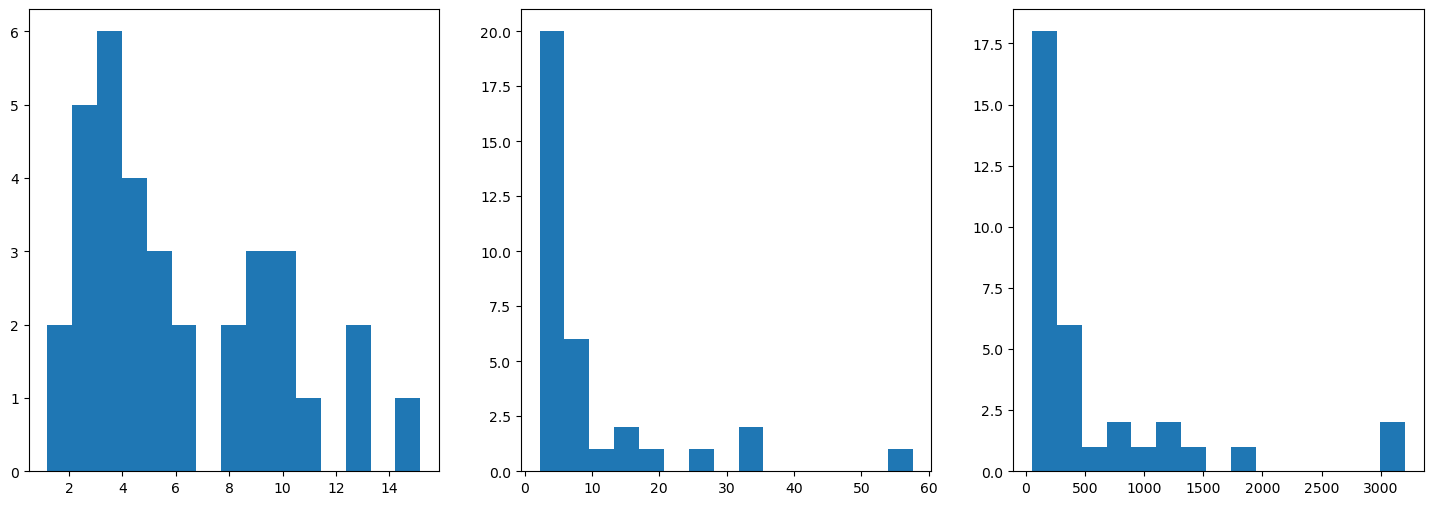

In [34]:
fig, axs = plt.subplots(1,3 , figsize= (18,6))
columns = ["population_density", "waste_per_pop", "waste_per_area"]

for ind in range(len(columns)):
    axs[ind].hist(waste_pop_gdf[columns[ind]], bins=15)

plt.show()

In [35]:
q95_wpp= np.quantile(waste_pop_gdf["waste_per_pop"], 0.95)

waste_pop_gdf_cliped = waste_pop_gdf.copy()
waste_pop_gdf_cliped["waste_per_pop"] = waste_pop_gdf_cliped["waste_per_pop"].clip(upper=q95_wpp)

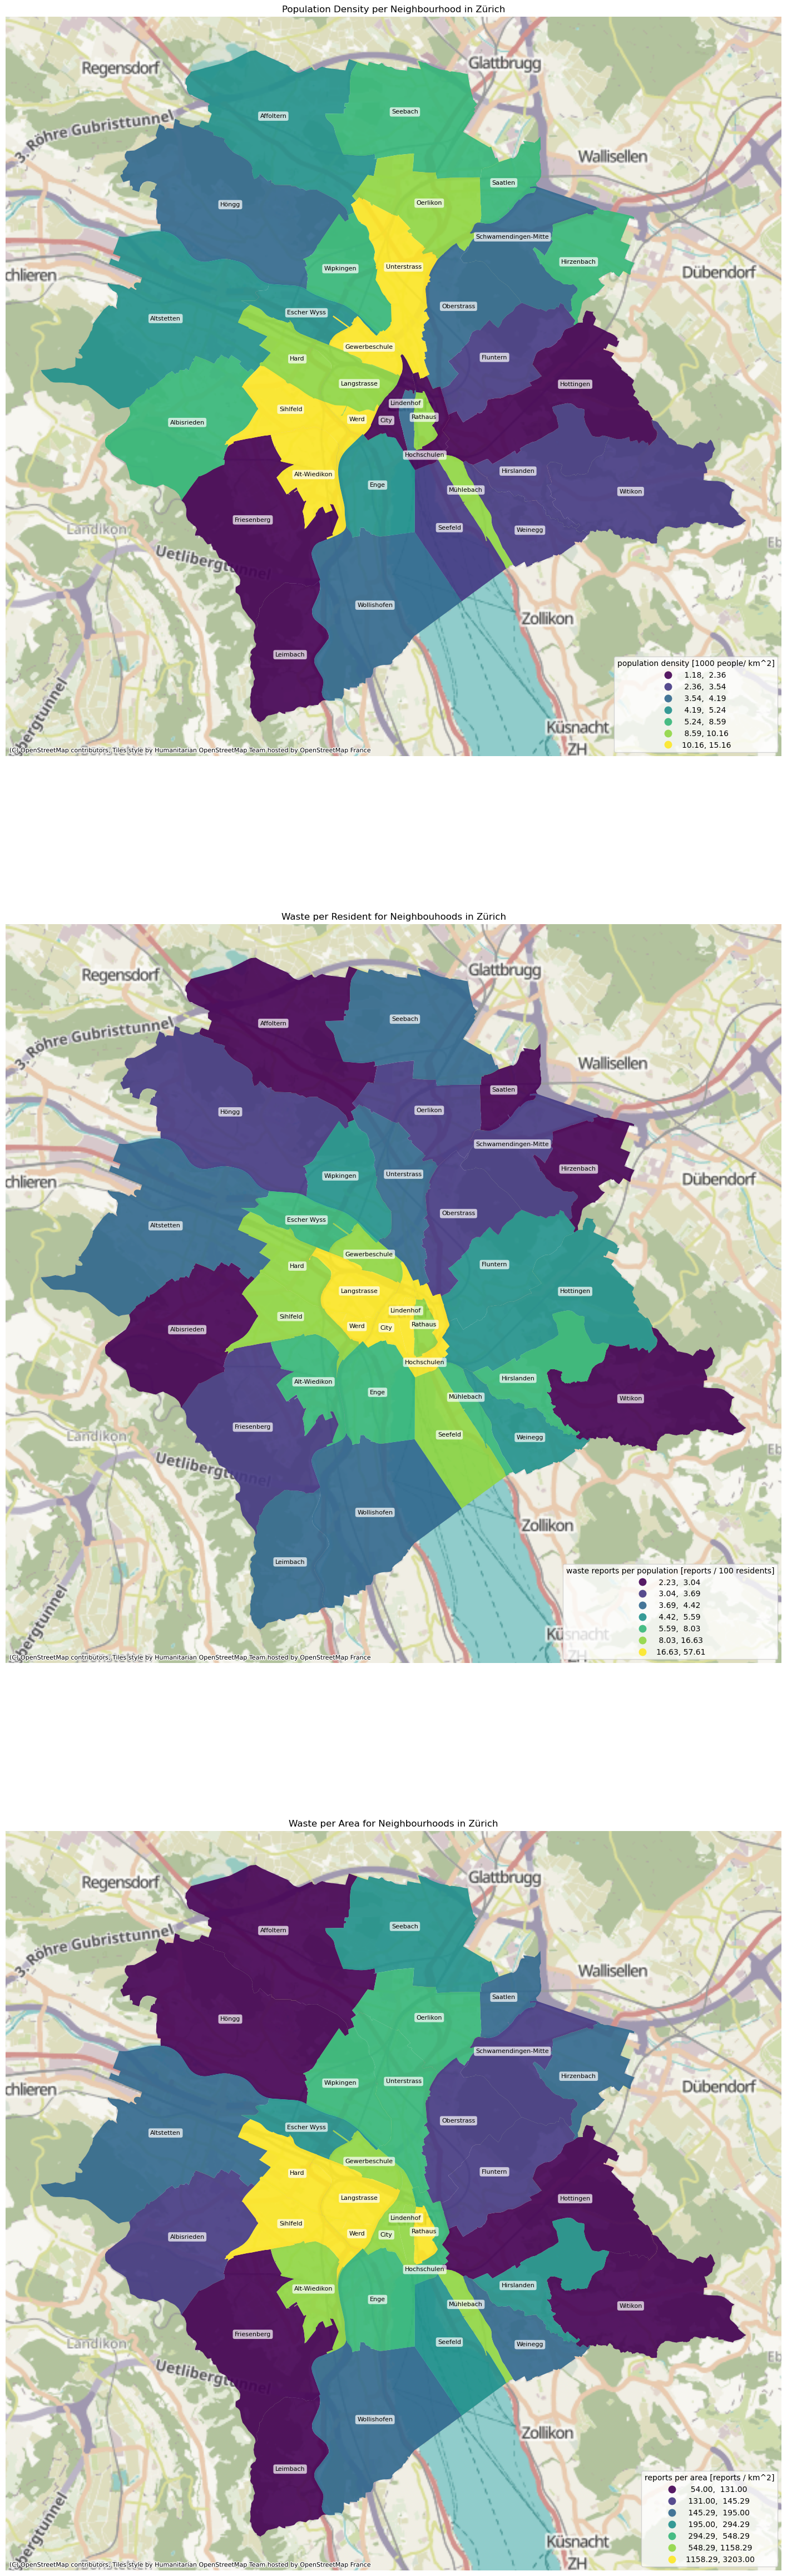

In [45]:
fig, axs = plt.subplots(3, 1, figsize= (18,60))

columns = ["population_density", "waste_per_pop", "waste_per_area"]
titles  = ["Population Density per Neighbourhood in Zürich", "Waste per Resident for Neighbouhoods in Zürich", "Waste per Area for Neighbourhoods in Zürich"]
legends = ["population density [1000 people/ km^2]", "waste reports per population [reports / 100 residents]", "reports per area [reports / km^2]"]

legend_options = {
    "label": "Population Age 0 to 14 (%)",  # The title text displayed next to the colorbar
    "orientation": "horizontal",  # Draws the colorbar left-to-right beneath the map
    "shrink": 0.6,  # Scales the length of the colorbar down to 60% of the axis width
    "pad": 0.05,  # Adds a 5% spacing gap between the map and the colorbar
}

for i in range(3):


    waste_pop_gdf.to_crs(epsg=3857).plot(ax= axs[i], column= columns[i], scheme="quantiles", k=7, legend=True,
    legend_kwds={"title": legends[i], "loc": "lower right"}, alpha=0.9)
    axs[i].axis("off")
    axs[i].set_title(titles[i])
    axs[i].plot
    ctx.add_basemap(axs[i])

    for idx, row in neighbourhood_labels_gdf.to_crs(epsg=3857).iterrows():
        x, y = row.geometry.x, row.geometry.y
    
        if row['name'] == 'Lindenhof':
            y += 200
        
        axs[i].annotate(
        text=row['name'],
        xy=(x, y),
        fontsize=8,
        ha='center',
        color= "black",
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none')
    )

plt.show()

In [37]:
print(list(range(3)))

[0, 1, 2]


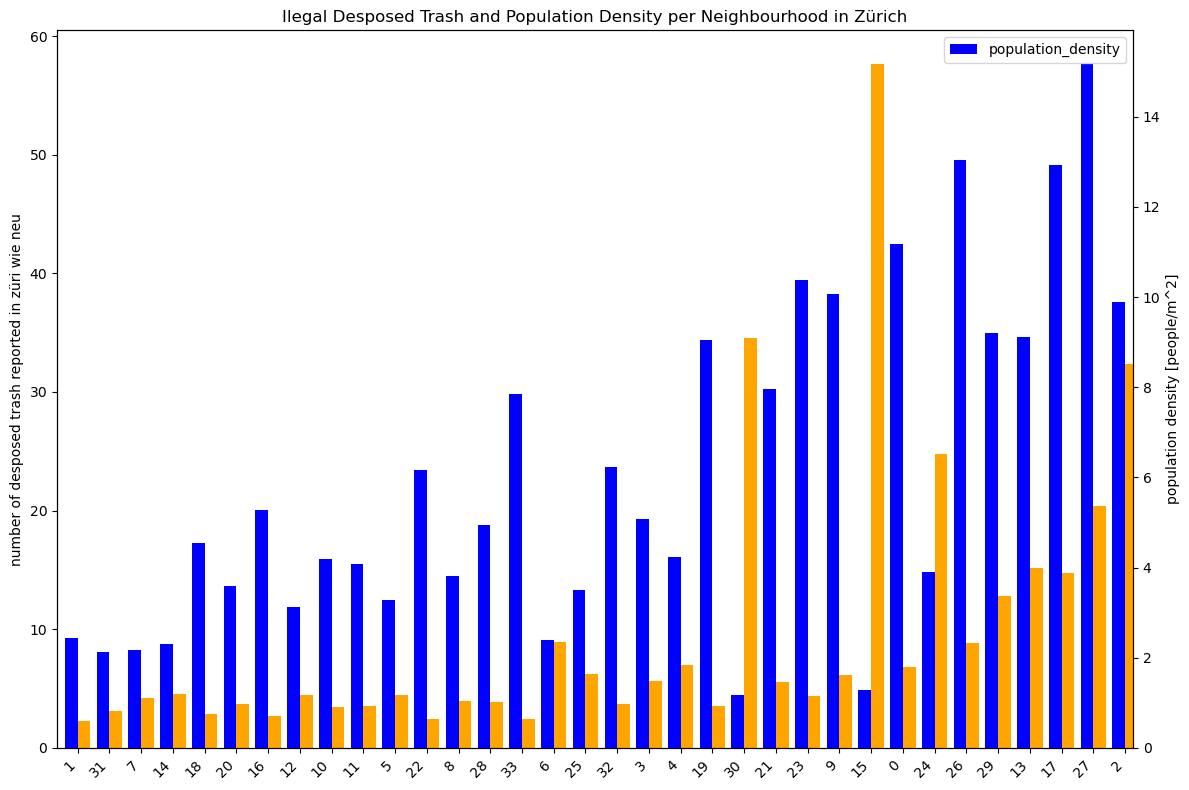

In [38]:
fig, ax1 = plt.subplots(figsize= (12,8))
ax2 = ax1.twinx()

waste_pop_gdf["waste_per_pop"].plot(kind="bar", ax=ax1, width= 0.4, position=0, color= "orange",
                               title="Ilegal Desposed Trash and Population Density per Neighbourhood in Zürich",
                               ylabel="number of desposed trash reported in züri wie neu",
                               xlabel="")
waste_pop_gdf["population_density"].plot(kind="bar", ax=ax2, width= 0.4, position=1, color= "blue",
                         ylabel="population density [people/m^2]"
                         )
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, horizontalalignment="right")
plt.tight_layout()
plt.legend()


plt.show()

KeyError: 'waste_density'

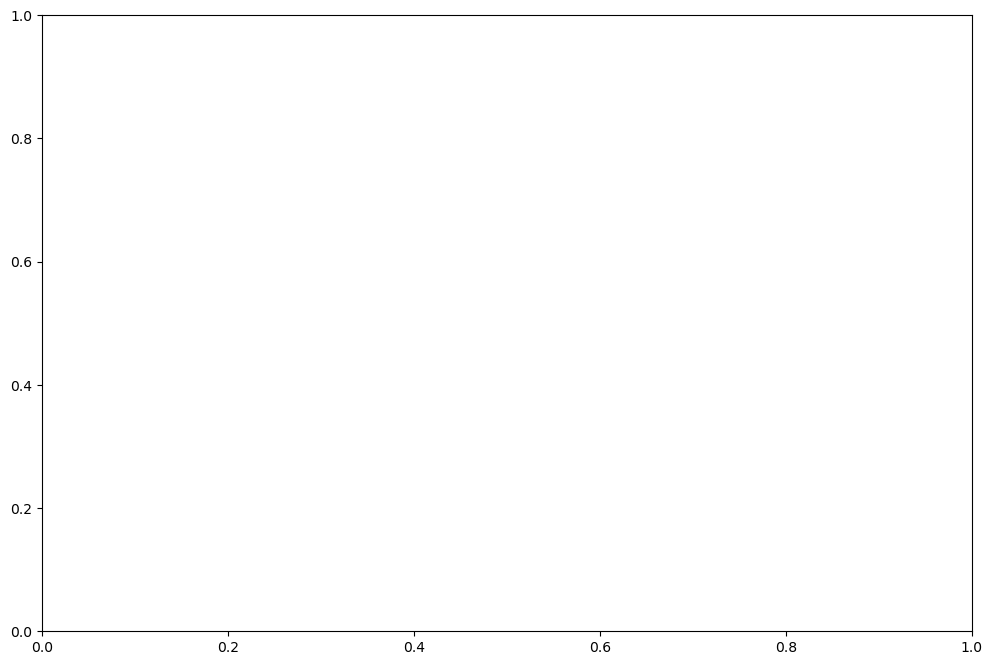

In [39]:
fig, ax3 = plt.subplots(figsize= (12,8))

ax3.scatter(waste_pop_gdf["waste_density"], waste_pop_gdf["population_density"])
m, b = np.polyfit(waste_pop_gdf["waste_density"], waste_pop_gdf["population_density"], 1)
x= waste_pop_gdf["waste_density"]
y= waste_pop_gdf["population_density"]
plt.plot(x, m*x + b, color='red', linestyle='-', label=f'Trendline: y={m:.2f}x+{b:.2f}')
plt.legend()
plt.show()


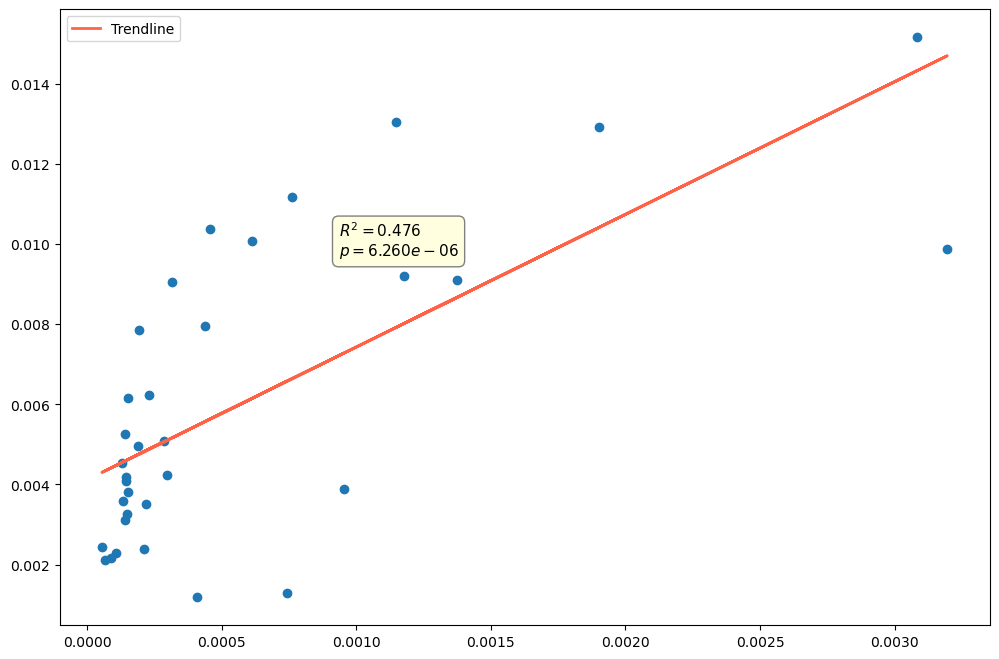

In [ ]:
fig, ax3 = plt.subplots(figsize= (12,8))

x= waste_pop_gdf["waste_density"]
y= waste_pop_gdf["population_density"]

ax3.scatter(x,y)

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2
y_line = slope * x + intercept
ax3.plot(x, y_line, color='tomato', linewidth=2, label='Trendline')
x= waste_pop_gdf["waste_density"]
y= waste_pop_gdf["population_density"]

ax3.annotate(
    f'$R^2 = {r_squared:.3f}$\n$p = {p_value:.3e}$',
    xy=(0.3, 0.6), xycoords='axes fraction', fontsize=11,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray')
    
)


plt.legend()
plt.show()